# 01 URDF Combination

In [4]:
import kinpy as kp

# urdf_path = 'urdfs/ur_description/urdf/ur5_robot.urdf'
# urdf_path = 'urdfs/DH13_right_palm_URDF/urdf/DH13_right_palm_URDF.urdf'
urdf_path = 'urdfs/ur5_dh13_combined.urdf'

txt = open(urdf_path, 'rb').read()
chain = kp.build_chain_from_urdf(txt)
print(chain)
# serial_chain = kp.build_serial_chain_from_urdf(txt, 'ee_link')
# print(serial_chain)

chain.get_joint_parameter_names()

# dir(chain)
# chain.forward_kinematics([0.1])



world_frame
└──── base_link_frame
      └──── shoulder_link_frame
            └──── upper_arm_link_frame
                  └──── forearm_link_frame
                        └──── wrist_1_link_frame
                              └──── wrist_2_link_frame
                                    └──── wrist_3_link_frame
                                          └──── ee_link_frame
                                                └──── right_palm_link_frame
                                                      ├──── right_index_link_0_frame
                                                      │     └──── right_index_link_1_frame
                                                      │           ├──── right_index_link_2_frame
                                                      │           │     ├──── right_index_link_3_frame
                                                      │           │     │     └──── right_index_tactile_link_2_frame
                                                      │ 

['shoulder_pan_joint',
 'shoulder_lift_joint',
 'elbow_joint',
 'wrist_1_joint',
 'wrist_2_joint',
 'wrist_3_joint',
 'right_index_joint_0',
 'right_index_joint_1',
 'right_index_joint_2',
 'right_index_joint_3',
 'right_middle_joint_0',
 'right_middle_joint_1',
 'right_middle_joint_2',
 'right_middle_joint_3',
 'right_ring_joint_0',
 'right_ring_joint_1',
 'right_ring_joint_2',
 'right_ring_joint_3',
 'right_thumb_joint_0',
 'right_thumb_joint_1',
 'right_thumb_joint_2',
 'right_thumb_joint_3']

In [3]:
import cloudpickle as cpickle

def load_cpkl(path):
    with open(path, 'rb') as f:
        return cpickle.load(f)
    
pkl_path = 'datasets/robot/robot/robot_rawdata.pkl'
data = load_cpkl(pkl_path)
data


{'save_freq': 0.5,
 'num_steps': 30591,
 'cam_K': array([[616.99243,   0.     , 314.10406],
        [  0.     , 616.9546 , 236.41193],
        [  0.     ,   0.     ,   1.     ]], dtype=float32),
 'eef_pose_list': [array([ 0.5592351 ,  0.01731292,  0.3996791 , -0.26527479,  0.88532478,
          0.30255493,  0.23300174]),
  array([ 0.55923513,  0.01731272,  0.3996791 , -0.26527456,  0.8853249 ,
          0.30255483,  0.23300175]),
  array([ 0.5592351 ,  0.01731298,  0.3996791 , -0.26527468,  0.88532484,
          0.30255498,  0.23300167]),
  array([ 0.55923514,  0.01731281,  0.39967918, -0.2652746 ,  0.88532484,
          0.30255482,  0.23300184]),
  array([ 0.55923518,  0.01731297,  0.39967916, -0.26527472,  0.88532484,
          0.30255485,  0.23300178]),
  array([ 0.55923515,  0.01731286,  0.39967913, -0.26527463,  0.88532484,
          0.30255496,  0.23300171]),
  array([ 0.55923513,  0.01731286,  0.39967908, -0.26527463,  0.88532484,
          0.30255489,  0.23300171]),
  array([ 0

In [2]:
import cloudpickle as cpickle

def load_cpkl(path):
    with open(path, 'rb') as f:
        return cpickle.load(f)
    
pkl_path = 'datasets/robot/robot/predefined_motion_graphs/000320.pkl'
data = load_cpkl(pkl_path)
data

{'joints': tensor([[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.1575],
         [ 0.0000,  0.0000,  0.3600],
         [ 0.0931, -0.0072,  0.5419],
         [ 0.1912, -0.0147,  0.7337],
         [ 0.3457, -0.0266,  0.6335],
         [ 0.5261, -0.0405,  0.5164],
         [ 0.5384,  0.0073,  0.4522],
         [ 0.5491,  0.0486,  0.3967],
         [ 0.5635,  0.1046,  0.3213],
         [ 0.5534,  0.1533,  0.3286],
         [ 0.5803,  0.0811,  0.2801],
         [ 0.5552,  0.2521,  0.2716],
         [ 0.6100,  0.1039,  0.1736]]),
 'links': [(0, 1),
  (1, 2),
  (2, 3),
  (3, 4),
  (4, 5),
  (5, 6),
  (6, 7),
  (7, 8),
  (8, 9),
  (9, 10),
  (9, 11),
  (10, 12),
  (11, 13)],
 'link_poses': tensor([[[ 1.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  1.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  1.0000,  0.1575],
          [ 0.0000,  0.0000,  0.0000,  1.0000]],
 
         [[ 1.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  1.0000,  0.0000,  0.0000],
     

In [1]:
from motionblender.app.utils import RobotInterface, MotionBlender
import os
import os.path as osp
import roma
import motionblender.lib.misc as misc
import torch.nn.functional as F
from loguru import logger
import torch.nn as nn
import torch.optim as optim
import numpy as np
import motionblender.lib.animate as anim
from jaxtyping import Float32
from tqdm.auto import tqdm, trange
import kinpy as kp
import torch
import transformations as tf
from torch import Tensor

def map_gripper_ctrl_to_joint_v(gv):
    v = max(min(gv, 100), 30)
    v = 0.8 * (v - 30) / 70
    return {
        'finger_1_joint_1': v,
        'finger_2_joint_1': v,
        'finger_middle_joint_1': v
    }

robot_joints = [
    'joint_0',
    'joint_1',
    'joint_2',
    'joint_3',
    'joint_4',
    'joint_5',
    'joint_6',
    'joint_7', 
    'ee',
    'palm',
    'left_finger_1',
    'right_finger_1',
    'left_finger_2',
    'right_finger_2',
]

robot_joints_from_origin = {
    'joint_0': 'iiwa_link_0',
    'joint_1': 'iiwa_link_1',
    'joint_2': 'iiwa_link_2',
    'joint_3': 'iiwa_link_3',
    'joint_4': 'iiwa_link_4',
    'joint_5': 'iiwa_link_5',
    'joint_6': 'iiwa_link_6',
    'joint_7': 'iiwa_link_7',
    'ee': 'iiwa_link_ee',
    'palm': 'palm',
    'left_finger_1': ['finger_middle_link_0'],
    'right_finger_1': ['finger_1_link_0', 'finger_2_link_0'],
    'left_finger_2': ['finger_middle_link_3'],
    'right_finger_2': ['finger_1_link_3', 'finger_2_link_3'],
}

robot_connections = [
    ['joint_0', 'joint_1'],
    ['joint_1', 'joint_2'],
    ['joint_2', 'joint_3'],
    ['joint_3', 'joint_4'],
    ['joint_4', 'joint_5'],
    ['joint_5', 'joint_6'],
    ['joint_6', 'joint_7'],
    ['joint_7', 'ee'],
    ['ee', 'palm'],
    ['palm', 'left_finger_1'],
    ['palm', 'right_finger_1'],
    ['left_finger_1', 'left_finger_2'],
    ['right_finger_1', 'right_finger_2'],
]

robot_connections_int = [(robot_joints.index(a), robot_joints.index(b)) for a, b in robot_connections]

default_joint_values = {'iiwa_joint_1': -0.15783709287643433,
 'iiwa_joint_2': 0.48583802580833435,
 'iiwa_joint_3': 1.0546152225288097e-05,
 'iiwa_joint_4': -1.6795016527175903,
 'iiwa_joint_5': 0.9391155242919922,
 'iiwa_joint_6': 1.027316689491272,
 'iiwa_joint_7': -1.273979663848877,
 'palm_finger_1_joint': -0.16,
 'palm_finger_2_joint': 0.16,
 'finger_middle_joint_3': 0,
 'finger_middle_joint_2': 0,
 'finger_2_joint_3': 0,
 'finger_2_joint_2': 0,
 'finger_1_joint_3': 0,
 'finger_1_joint_2': 0,
 'finger_1_joint_1': 0.0,
 'finger_2_joint_1': 0.0,
 'finger_middle_joint_1': 0.0}

class Kuka(RobotInterface):
    def __init__(self, iiwa_path=os.path.dirname(__file__) + "/iiwa/kuka.urdf"):
        super().__init__()
        txt = open(iiwa_path).read()
        self.iiwa_serial_chain = kp.build_serial_chain_from_urdf(txt, 'palm')
        self.iiwa_chain = kp.build_chain_from_urdf(txt)
        self.joint_names = [f'iiwa_joint_{i}' for i in range(1, 8)]
        self.curr_jvs = np.array([default_joint_values[jname] for jname in self.joint_names])
        self.buf['rot6d'] = None
    
    def _joint_values_to_rot6d(self, joint_values):
        link_poses = self.iiwa_chain.forward_kinematics(joint_values)
        robot_joints_values = {}
        for rj_name, parents in robot_joints_from_origin.items(): 
            if isinstance(parents, list):
                values = []
                for p in parents:
                    values.append(link_poses[p].pos)
                robot_joints_values[rj_name] = sum(values) / len(values)
            else:
                robot_joints_values[rj_name] = link_poses[parents].pos

        joint_positions = []
        for rj_name in robot_joints:
            joint_positions.append(robot_joints_values[rj_name])
        joint_positions = torch.from_numpy(np.array(joint_positions)).float()
        anim_chain = anim.inverse_kinematic(joint_positions, robot_connections_int)
        rot6d = anim.retrieve_tensor_from_chain(anim_chain, 'rot6d')
        return rot6d

    def initialize(self, motion_module: MotionBlender) -> None:
        gripper_poses = getattr(motion_module, 'gripper_poses', [])
        if len(gripper_poses) == 0:
            if hasattr(motion_module, 'original_cano_t'):
                original_cano_t = motion_module.original_cano_t
            else:
                original_cano_t = 323

            ROBOT_ROOT_DATASET_DIR = './datasets/robot/'
            img_id = misc.load_json(osp.join(ROBOT_ROOT_DATASET_DIR, 'dataset.json'))['ids'][original_cano_t]
            jv = misc.load_cpkl(osp.join(ROBOT_ROOT_DATASET_DIR, 'robot_rawdata.pkl'))['joint_pos_list'][int(img_id)]
            self.curr_jvs = np.array(jv)
            end_pose_tf = self.iiwa_serial_chain.forward_kinematics(self.curr_jvs)
            ee_pose_robot_base = torch.from_numpy(end_pose_tf.matrix()).float().to(next(motion_module.parameters()).device)
            self.buf['pose'] = ee_pose_robot_base
            self.buf['degree'] = 50.
        else:
            self.buf['pose'] = gripper_poses[0]
            self.buf['degree'] = motion_module.gripper_degrees[0]

        self.get_joint_rotations()
        self.inited = True
    
    def get_joint_rotations(self, refresh=False) -> Float32[Tensor, "j 6"]:
        if not self.buf['stale'] and self.buf['rot6d'] is not None and not refresh:
            return self.buf['rot6d']

        matrix = self.buf['pose'].cpu().numpy()
        trans = kp.Transform(rot=tf.quaternion_from_matrix(matrix), pos=matrix[:3, 3])
        self.curr_jvs = self.iiwa_serial_chain.inverse_kinematics(trans, self.curr_jvs)
        joint_values = {**default_joint_values, **map_gripper_ctrl_to_joint_v(self.buf['degree']), 
                        **dict(zip(self.joint_names, self.curr_jvs))}
        rot6d = self._joint_values_to_rot6d(joint_values)
        self.buf['rot6d'] = rot6d.to(self.buf['pose'].device)
        self.buf['stale'] = False
        return self.buf['rot6d']

robot = Kuka()

if __name__ == "__main__":
    gs_modules, motion_modules, _, gaussian_names = misc.load_cpkl("outputs/mb/robot/okish/toy/ckpt.robot.cpkl")
    robot.initialize(motion_modules['robot'])
    robot.buf['pose'][:3, 3] += (torch.rand(3).cuda() * 0.3)
    robot.buf['pose'][:3, :3] = roma.random_rotmat().cuda() @ robot.buf['pose'][:3, :3]
    print(robot.get_joint_rotations(refresh=True))

torch_batch_svd not installed. Using torch.svd instead


/home/zhangwenkang/miniconda3/envs/rsrd/lib/python3.10/site-packages/transformations/transformations.py:1924: UserWarning: No module named 'transformations._transformations'
  warnings.warn(str(exc))


NameError: name '__file__' is not defined

In [ ]:
import math
def degree_to_radian(degree):
    return degree * math.pi / 180.0



# 02 SAPIEN

In [3]:
import sapien as sapien
from sapien.utils import Viewer
import numpy as np


def main():
    scene = sapien.Scene()  # Create an instance of simulation world (aka scene)
    scene.set_timestep(1 / 100.0)  # Set the simulation frequency

    # NOTE: How to build (rigid bodies) is elaborated in create_actors.py
    scene.add_ground(altitude=0)  # Add a ground
    actor_builder = scene.create_actor_builder()
    actor_builder.add_box_collision(half_size=[0.5, 0.5, 0.5])
    actor_builder.add_box_visual(half_size=[0.5, 0.5, 0.5], material=[1.0, 0.0, 0.0])
    box = actor_builder.build(name="box")  # Add a box
    box.set_pose(sapien.Pose(p=[0, 0, 0.5]))

    # Add some lights so that you can observe the scene
    scene.set_ambient_light([0.5, 0.5, 0.5])
    scene.add_directional_light([0, 1, -1], [0.5, 0.5, 0.5])

    viewer = scene.create_viewer()  # Create a viewer (window)

    # The coordinate frame in Sapien is: x(forward), y(left), z(upward)
    # The principle axis of the camera is the x-axis
    viewer.set_camera_xyz(x=-4, y=0, z=2)
    # The rotation of the free camera is represented as [roll(x), pitch(-y), yaw(-z)]
    # The camera now looks at the origin
    viewer.set_camera_rpy(r=0, p=-np.arctan2(2, 4), y=0)
    viewer.window.set_camera_parameters(near=0.05, far=100, fovy=1)

    while not viewer.closed:  # Press key q to quit
        scene.step()  # Simulate the world
        scene.update_render()  # Update the world to the renderer
        viewer.render()


if __name__ == "__main__":
    main()

In [12]:
import sapien


def demo(fix_root_link, balance_passive_force):
    scene = sapien.Scene()
    scene.add_ground(0)

    scene.set_ambient_light([0.5, 0.5, 0.5])
    scene.add_directional_light([0, 1, -1], [0.5, 0.5, 0.5])

    viewer = scene.create_viewer()
    viewer.set_camera_xyz(x=-2, y=0, z=1)
    viewer.set_camera_rpy(r=0, p=-0.3, y=0)

    # Load URDF
    loader = scene.create_urdf_loader()
    loader.fix_root_link = fix_root_link
    # robot: sapien.Articulation = loader.load("./my_data/DH13_right_palm_URDF/urdf/DH13_right_palm_URDF.urdf")
    # robot: sapien.Articulation = loader.load("./my_data/ur_description/urdf/ur5_robot.urdf")
    robot: sapien.Articulation = loader.load("./my_data/ur5_dh13_combined.urdf")
    robot.set_root_pose(sapien.Pose([0, 0, 0], [1, 0, 0, 0]))

    # # Set initial joint positions
    # arm_init_qpos = [4.71, 2.84, 0, 0.75, 4.62, 4.48, 4.88]
    # gripper_init_qpos = [0, 0, 0, 0, 0, 0]
    # init_qpos = arm_init_qpos + gripper_init_qpos
    # robot.set_qpos(init_qpos)

    while not viewer.closed:
        for _ in range(4):  # render every 4 steps
            if balance_passive_force:
                qf = robot.compute_passive_force(
                    gravity=True,
                    coriolis_and_centrifugal=True,
                )
                robot.set_qf(qf)
            scene.step()
        scene.update_render()
        viewer.render()


demo(fix_root_link=True, balance_passive_force=True)

In [ ]:
"""
  <!-- Connection Bracket Link -->
  <link name="connection_bracket_link">
    <visual>
      <geometry>
        <!-- 进一步缩小连接件，并调整其局部位置 -->
        <mesh filename="package://connector/UR5_DH13_tutai.STL" scale="0.0004 0.0004 0.0004"/>
      </geometry>
      <origin xyz="0.0 0.0 0.0" rpy="0.0 0.0 0.0"/>
    </visual>
    <collision>
      <geometry>
        <mesh filename="package://connector/UR5_DH13_tutai.STL" scale="0.0004 0.0004 0.0004"/>
      </geometry>
      <origin xyz="0.0 0.0 0.0" rpy="0.0 0.0 0.0"/>
    </collision>
    <inertial>
      <mass value="0.05"/>
      <origin xyz="0.0 0.0 0.0"/>
      <inertia ixx="0.0005" ixy="0.0" ixz="0.0" iyy="0.0005" iyz="0.0" izz="0.0005"/>
    </inertial>
  </link>

  <!-- Connect UR5 end-effector to connection bracket -->
  <joint name="ur5_to_bracket" type="fixed">
    <parent link="ee_link"/>
    <child link="connection_bracket_link"/>
    <origin xyz="0.03 -0.02 0.0" rpy="0.0 0.0 1.5708"/>
  </joint>

    <!-- Connect connection bracket to DH13 hand -->
  <joint name="bracket_to_dh13" type="fixed">
    <parent link="connection_bracket_link"/>
    <child link="right_palm_link"/>
    <!-- 调整DH13手部相对于连接件的位置和方向 -->
    <origin xyz="0.0 0.0 0.015" rpy="0.0 0.0 -1.5708"/>
  </joint>

"""

# 03 Data Process

In [ ]:
# Convert a sequence of images into a video using OpenCV

import cv2
import os

def images_to_video(image_folder, video_name, fps=30):
    images = [img for img in os.listdir(image_folder) if img.endswith(".jpg") or img.endswith(".png")]
    images.sort()  # Sort images by name

    if not images:
        print("No images found in the specified folder.")
        return

    first_image = cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = first_image.shape

    video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))

    video.release()
    print(f"Video {video_name} created successfully.")

if __name__ == "__main__":
    image_folder = 'datasets/robot/robot/rgb'  # Path to the images folder
    video_name = 'output_video.mp4'  # Output video file name
    images_to_video(image_folder, video_name)

Video output_video.mp4 created successfully.


In [19]:
import os
import cv2
import json
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import sys

base_path = 'my_data/ep4'
output_path = 'datasets/robot/ur5_ep4'
os.makedirs(output_path, exist_ok=True)

video_path = os.path.join(base_path, 'video.mp4')
csv_path = os.path.join(base_path, 'ur5_frame_data.csv')

df = pd.read_csv(csv_path)
df.head()

def extract_and_align(video_path, df, output_dir, save_per_frame_json=False, fallback_fill_last=True):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"无法打开视频: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"视频: {video_path}\n尺寸: {width}x{height}, FPS: {fps:.3f}, 帧数: {frame_count}")

    # 准备聚合 JSON 容器
    aligned = {
        'video_path': video_path,
        'csv_path': csv_path,
        'fps': float(fps),
        'frame_count': int(frame_count),
        'frames': []
    }

    idx_map = lambda i: i

    for i in tqdm(range(frame_count), desc='Extracting frames'):
        ret, frame = cap.read()
        assert ret, f"第 {i} 帧读取失败"

        # 保存帧图像
        img_name = f"frame_{i:06d}.png"
        img_dir = os.path.join(output_dir, 'rgb')
        os.makedirs(img_dir, exist_ok=True)
        img_path = os.path.join(img_dir, img_name)
        cv2.imwrite(img_path, frame)

        # 选择 CSV 行
        j = idx_map(i)
        if j >= len(df):
            if fallback_fill_last and len(df) > 0:
                j = len(df) - 1
            else:
                # 无可对齐数据，记录空
                pose_dict = {}
                frame_item = {
                    'frame_index': i,
                    'image': img_path,
                    'pose': pose_dict
                }
                aligned['frames'].append(frame_item)
                if save_per_frame_json:
                    with open(os.path.join(output_dir, f"frame_{i:06d}.json"), 'w', encoding='utf-8') as f:
                        json.dump(frame_item, f, ensure_ascii=False, indent=2)
                continue

        pose_series = df.iloc[j]
        # 确保可序列化
        pose_dict = {k: (None if pd.isna(v) else (float(v) if isinstance(v, (int, float, np.floating)) else v))
                     for k, v in pose_series.to_dict().items()}

        frame_item = {
            'frame_index': i,
            'csv_index': int(j),
            'image': img_path,
            'pose': pose_dict
        }
        aligned['frames'].append(frame_item)

        if save_per_frame_json:
            with open(os.path.join(output_dir, f"frame_{i:06d}.json"), 'w', encoding='utf-8') as f:
                json.dump(frame_item, f, ensure_ascii=False, indent=2)

    cap.release()

    # 写聚合 JSON
    out_json = os.path.join(output_dir, 'frame_pose_alignment.json')
    with open(out_json, 'w', encoding='utf-8') as f:
        json.dump(aligned, f, ensure_ascii=False, indent=2)

    print(f"Extracted images to: {img_dir}")
    print(f"Extracted aligned JSON: {out_json}")
    return aligned

def prepare_sam2_json(output_path, image_dir, start = 0, end = 499, exp_name='ur5'):
    sam2_json_data = {
        "name": f"{exp_name}:center",
        "instances": [
            f"{exp_name}:kinematic"
        ],
        "root": None,
        "frames": [],
        "output_path": "instance"
    }

    for idx in range(start, end + 1):
        rgb_path = os.path.join(image_dir, f"frame_{idx:06d}.png")
        if os.path.exists(rgb_path):
            sam2_json_data['frames'].append(f'rgb/frame_{idx:06d}.png')
        else:
            print(f"Warning: {rgb_path} does not exist.")

    with open(os.path.join(output_path, 'sam2_task_center.json'), 'w') as f:
        json.dump(sam2_json_data, f, indent=4)
        print(f"Saved SAM2 JSON to {os.path.join(output_path, 'sam2_task_center.json')}")

    return sam2_json_data

def prepare_camera_json(output_path, start = 0, end = 499):
    camera_json = {
        "focal_length": 606.45947266,
        "image_size": [
            640,
            480
        ],
        "orientation": [
            [0.02082761, -0.99729553, 0.07048289],
            [0.10104566, -0.06803744, -0.99255261],
            [0.99466376, 0.02779449, 0.09935532]
        ],
        "position": [
            -0.36250033,
            0.15640983,
            0.7456299
        ],
        "pixel_aspect_ratio": 1.0,
        "principal_point": [
            324.13546753,
            249.23587036
        ],
        "radial_distortion": [
            0.0,
            0.0,
            0.0
        ],
        "skew": 0.0,
        "tangential_distortion": [
            0.0,
            0.0
        ]
    }

    camera_dir = os.path.join(output_path, 'camera')
    os.makedirs(camera_dir, exist_ok=True)

    for idx in range(start, end + 1):
        with open(os.path.join(camera_dir, f"frame_{idx:06d}.json"), 'w') as f:
            json.dump(camera_json, f, indent=4)
    print(f"Saved camera JSON files to {camera_dir}")

    return camera_json

def prepare_depth(video_path, output_path):
    original_cwd = os.getcwd()
    video_depth_anything_path = os.path.join(original_cwd, 'Video-Depth-Anything')
    os.chdir(video_depth_anything_path)
    os.system(f'python3 run.py --input_video ../{video_path} --output_dir ../{output_path} --encoder vits --save_npz')

    os.chdir(original_cwd)

def extract_depth_images(video_path, output_dir):
    npz_path = os.path.join(output_dir, 'depth', 'video_depths.npz')
    if not os.path.exists(npz_path):
        print(f"Depth data not found at {npz_path}. Please run prepare_depth first.")
        prepare_depth(video_path, os.path.join(output_dir, 'depth'))
        
    depth_data = np.load(npz_path, allow_pickle=True)
    depth_images = depth_data['depths']
    depth_dir = os.path.join(output_dir, 'aligned_depth_anything')
    os.makedirs(depth_dir, exist_ok=True)
    # save each depth image as npy
    for i, depth_image in enumerate(tqdm(depth_images, desc="Saving depth images as npy")):
        depth_image_path = os.path.join(depth_dir, f"frame_{i:06d}.npy")
        np.save(depth_image_path, depth_image)

In [22]:
# # 执行逐帧提取与位姿对齐
# aligned = extract_and_align(
#     video_path,
#     df,
#     output_path,
#     save_per_frame_json=False,
#     fallback_fill_last=True
# )

sam2_json = prepare_sam2_json(output_path, 
    os.path.join(output_path, 'rgb'), 
    start=0, 
    end=499, 
    exp_name='ur5-ep4'
)

camera_json = prepare_camera_json(output_path, start=0, end=499)


Saved SAM2 JSON to datasets/robot/ur5_ep4/sam2_task_center.json
Saved camera JSON files to datasets/robot/ur5_ep4/camera


In [ ]:
# Grounded-SAM-2 for instance segmentation
import os
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':Grounded-SAM-2/'
os.system(f'port=8891 ckpt_dir=Grounded-SAM-2/checkpoints bash ./motionblender/preproc/sam2gui/run_gui_app.sh ./{output_path}/sam2_task_center.json')


/home/zhangwenkang/Projects/motion-blender-gs/Grounded-SAM-2/sam2/modeling/sam/transformer.py:23: UserWarning: You are using PyTorch 2.1.2+cu121 without Flash Attention v2 support. Consider upgrading to PyTorch 2.2+ for Flash Attention v2 (which could be faster).
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/home/zhangwenkang/miniconda3/envs/rsrd/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
2025-08-14 15:11:53.200 | INFO     | __main__:init_sam_model:127 - loaded model checkpoint Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt
2025-08-14 15:11:53.240 | DEBUG    | __main__:set_input_image:191 - Setting frame 0 / 0


* Running on local URL:  http://127.0.0.1:8891

To create a public link, set `share=True` in `launch()`.


2025-08-14 15:12:12.325 | DEBUG    | __main__:select_media:396 - Selected task: ur5-ep4:center
2025-08-14 15:12:15.975 | DEBUG    | __main__:set_input_image:191 - Setting frame 0 / 500
frame loading (JPEG / PNG): 100%|██████████| 500/500 [00:05<00:00, 92.95it/s]
/home/zhangwenkang/Projects/motion-blender-gs/Grounded-SAM-2/sam2/sam2_video_predictor.py:961: UserWarning: cannot import name '_C' from 'sam2' (/home/zhangwenkang/Projects/motion-blender-gs/Grounded-SAM-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
2025-08-14 15:12:33.212 | DEBUG    | __main__:get_select_coords:424 - index_mask.shape=(480, 640)
/home/zhangwenkang/Projects/motion-blender-gs/Grounded-SAM-2/sam2/sam2_

Keyboard interruption in main thread... closing server.


2

In [ ]:
# extract depth images
extract_depth_images(video_path,output_path)

Saving depth images as npy: 100%|██████████| 2031/2031 [00:01<00:00, 1691.61it/s]


(480, 640)


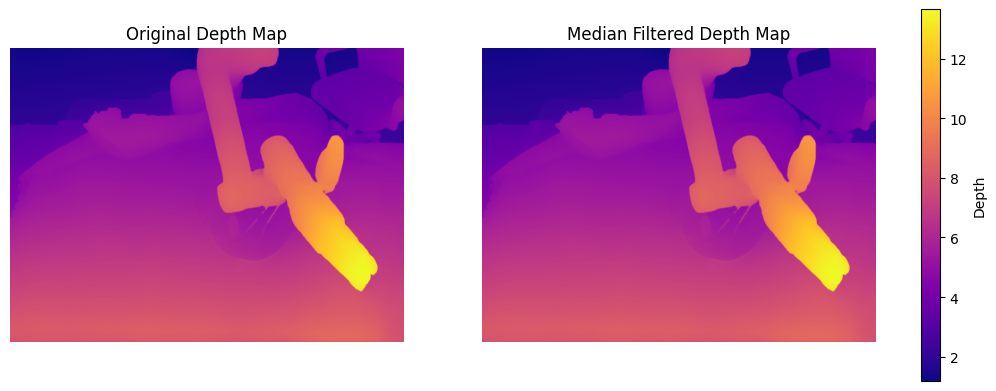

In [15]:
# load npy file
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter


def load_npy(path):
    return np.load(path, allow_pickle=True)

# npy_path = 'datasets/robot/robot/metric_depth/026560.npy'
npy_path = 'datasets/robot/ur5_ep4/aligned_depth_anything/frame_002030.npy'
data = load_npy(npy_path)
print(data.shape)

masked_data = np.ma.masked_where(data > 10000, data)

# 对原始深度数据进行中值滤波
filtered_data = median_filter(data, size=3)
filtered_masked_data = np.ma.masked_where(filtered_data > 10000, filtered_data)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(masked_data, cmap='plasma')
axs[0].set_title('Original Depth Map')
axs[0].axis('off')
axs[1].imshow(filtered_masked_data, cmap='plasma')
axs[1].set_title('Median Filtered Depth Map')
axs[1].axis('off')
plt.colorbar(axs[1].images[0], ax=axs, label='Depth', orientation='vertical', fraction=0.02)
plt.show()
